# Area-weighted Curvature distribution (Not fully tested)
The idea is that we create a histogram of the mean curvature in the membrane. And then weigh each gridpoint of curvature by the surface area in that gridpoint calculated from a parametrized surface.  

In [7]:
import sys
sys.path.append('..')
from include import *
from analyzer_functions import *

# Loading the config file
with open("system.conf", "r") as f:
    cfg = yaml.safe_load(f)

# Paths
sys_path = get_path(sub_path=cfg["paths"]["system"])
out_path = get_path(sub_path=cfg["paths"]["output"], main_path=sys_path)
rep_path = get_path(sub_path=cfg["paths"]["replicate"], main_path=out_path)
calm_path = get_path(sub_path=cfg["paths"]["calm"], main_path=rep_path)
calm_fit_path = get_path(sub_path=cfg["paths"]["calm_fit"], main_path=rep_path)

# files
dim = get_path(sub_path=cfg["files"]["dim"], main_path=calm_path)


In [3]:
# The new CALM version gives us the fitted structure through the "link" command, 
# where we can select the upper and lower leaflets via their resname

In [10]:
# Loading system information
gro = os.path.join(calm_fit_path, "first_frame.gro")
xtc = os.path.join(calm_fit_path, "trajectory.xtc")   # This trajectory is generated from the information in the CALM output
                                                      # so it doesn't contain the full trajectory.
                                                      # Each index corresponds to the specific frame from lowest to highest in the CALM folder
system = mda.Universe(gro, xtc)
upper = system.select_atoms("resname upper")
lower = system.select_atoms("resname lower")

# Get the number of frames and the frames to be analyzed                 
max_frame = len(system.trajectory) 
n_gridpoints = len(upper.atoms)
curv_filenames = get_CALM_frame_names(calm_path, filter="mean") 
trj_idxs, boxsizes = load_CALM_dimensions(dim)

# Allocating arrays
grid_curvatures = {
        "Upper": np.zeros(n_gridpoints*max_frame),
        "Lower": np.zeros(n_gridpoints*max_frame)
}
grid_weights = {
    "Upper": np.zeros(n_gridpoints*max_frame),
    "Lower": np.zeros(n_gridpoints*max_frame)
}

# Grouping the two leaflets together for easier looping
systems = {
    "Upper": upper,
    "Lower": lower
}

# Main loop
print("Currently assuming that the grid_area and curv_map have the same indexing!!!")
for i in tqdm(range(max_frame)):
    system.trajectory[i]   # Move to the specific frame in the trajectory
    # Load curvature maps
    curvature_data = load_npy(curv_filenames[i])
    curv_map = {
        "Upper": curvature_data[0],
        "Lower": curvature_data[1],
    }
    # Load the curvature map
    for key in systems:  # Flatten the curvature arrays
        curv_map[key] = curv_map[key].flatten()
        grid_curvatures[key][i*n_gridpoints:(i+1)*n_gridpoints] = curv_map[key]

    # Calculate the grid area
    for key in systems:
        height = systems[key].atoms.positions[:, -1] # We only need the z position as this is the height of the membrane
        height = np.reshape(height, (100, 100)) # Loading the height as a 100x100 grid
        grid_area, hx, hy = calc_surface_area(boxsizes[0], height)
        grid_area = grid_area.flatten() # Flatten the grid area to match the curvature map
        grid_weights[key][i*n_gridpoints:(i+1)*n_gridpoints] = grid_area
    


Currently assuming that the grid_area and curv_map have the same indexing!!!


100%|██████████| 117/117 [00:00<00:00, 202.34it/s]


1170000


Text(0, 0.5, 'Density of grid points - $P(c)$')

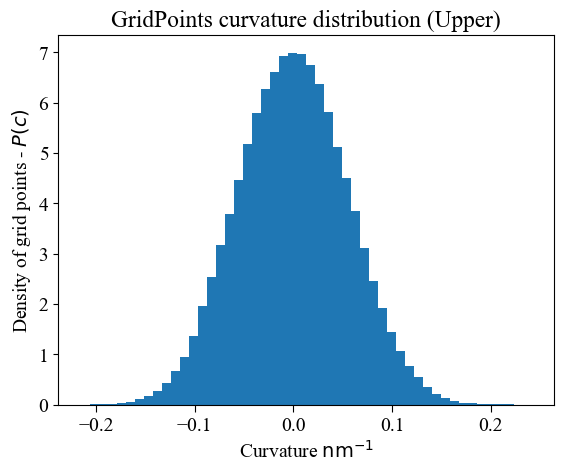

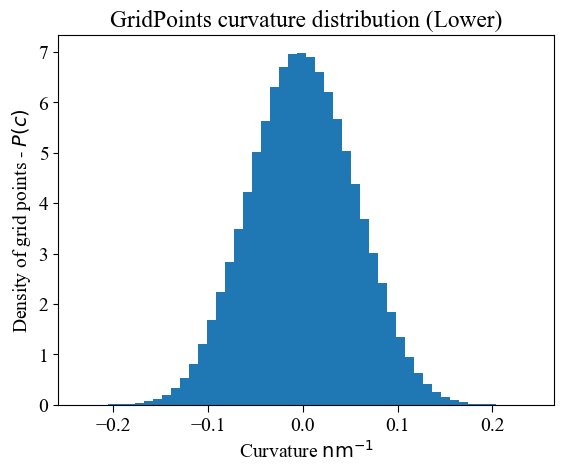

In [14]:
# Plotting params
n_bins = 50
print(len(grid_curvatures["Upper"]))
# Grid points histogram (Upper)
fig, ax = plt.subplots()
ax.hist(grid_curvatures["Upper"], bins=n_bins, density=True, weights=grid_weights["Upper"])
ax.set_title("GridPoints curvature distribution (Upper)")
ax.set_xlabel(r"Curvature $\text{nm}^{-1}$", fontsize = 14)
ax.set_ylabel("Density of grid points - $P(c)$")


# Grid points histogram (Lower)
fig, ax = plt.subplots()
ax.hist(grid_curvatures["Lower"], bins=n_bins, density=True, weights=grid_weights["Lower"])
ax.set_title("GridPoints curvature distribution (Lower)")
ax.set_xlabel(r"Curvature $\text{nm}^{-1}$", fontsize = 14)
ax.set_ylabel("Density of grid points - $P(c)$")

Text(0, 0.5, 'Density of grid points - $P(c)$')

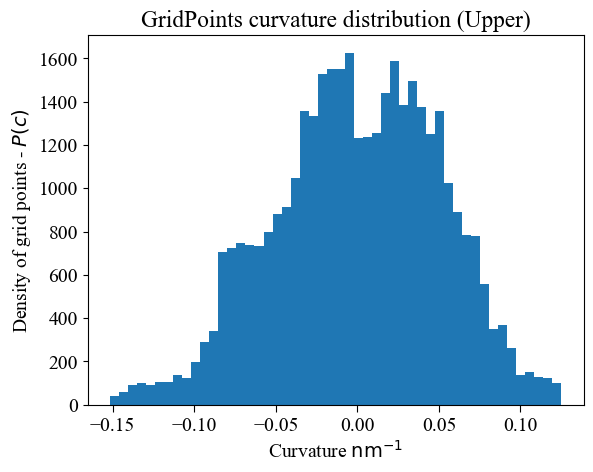

In [ ]:
# Plotting params
n_bins = 50

# Grid points histogram (Upper)
fig, ax = plt.subplots()
ax.hist(grid_curvatures["Upper"][0:10000], bins=n_bins)
ax.set_title("GridPoints curvature distribution (Upper)")
ax.set_xlabel(r"Curvature $\text{nm}^{-1}$", fontsize = 14)
ax.set_ylabel("Density of grid points - $P(c)$")
